## This notebook shows how to calculate pressures using the mixed H2O-CO2 equation of state
- It loads in pickles parameterizing the relationship between XH2O and pressure, and between host Fo and host Mg# and temperature

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import DiadFit as pf


## Loading XH2O pickles

In [2]:
import pickle
# These pickels give XCO2, when the function is applied to a pressure in MPa
# This one gives the lowest XH2O when applied
with open('xH2O_low.pkl', 'rb') as f:
    Pf_low = pickle.load(f)

# This is the max XH2O
with open('xH2O_high.pkl', 'rb') as f:
    Pf_high = pickle.load(f)

# This is the midpoint XH2O
with open('xH2O_mean.pkl', 'rb') as f:
    Pf_med = pickle.load(f)

## Lets just use these as an example

Text(0, 0.5, 'XH2O')

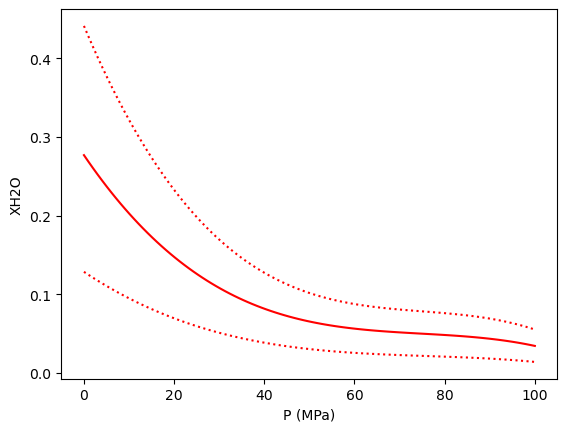

In [3]:
P=np.linspace(0, 100, 100) # Pressure is in MPA

XCO2_low=1-Pf_low(P)
XCO2_med=1-Pf_med(P)
XCO2_high=1-Pf_high(P)

plt.plot(P, XCO2_low, ':r')
plt.plot(P, XCO2_med, '-r')
plt.plot(P, XCO2_high, ':r')
plt.xlabel('P (MPa)')
plt.ylabel('XH2O')

## Loading Temp_Fo and Temp_Opx model

In [4]:
with open('TempFoModel.pkl', 'rb') as f:
    Pf_TempFo = pickle.load(f)

with open(r'TempOpxMgnoModel.pkl', 'rb') as f:
    Pf_Tempopx = pickle.load(f)

Text(0, 0.5, 'Temp (C)')

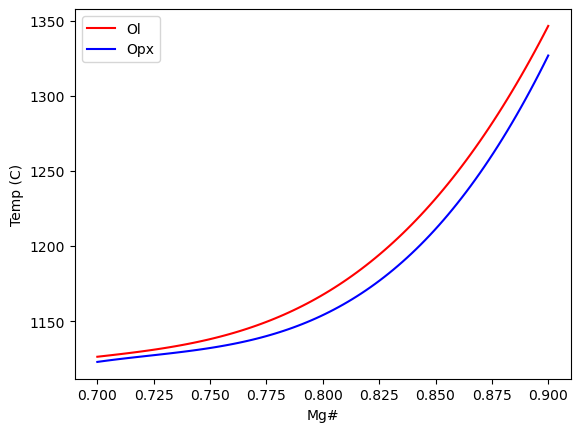

In [5]:
Mgno=np.linspace(0.7, 0.9, 100) # Pressure is in MPA

Temp_fo=Pf_TempFo(Mgno)
Temp_opx=Pf_Tempopx(Mgno)


plt.plot(Mgno, Temp_fo, '-r', label='Ol')
plt.plot(Mgno, Temp_opx, '-b', label='Opx')
plt.legend()

plt.xlabel('Mg#')
plt.ylabel('Temp (C)')

## Lets load some example data for performing EOS calculations

In [6]:
df=pd.read_excel('Supporting_Data_1.xlsx', sheet_name='FI_comp_data')
df.head()

## Calculate Fo
df['Fo']=(df['MgO']/40.3044)/((df['MgO']/40.3044)+(df['FeOt']/71.844))
df['Px_Mgno']=df['Fo']

# Calculate Mg#



In [7]:
# Create the new column and initialize with NaN
df['Temp_from_crystalchem_all'] = np.nan

# Calculate temperatures where 'Mineral_Host' is 'Ol'
mask_ol = (df['Mineral_Host'] == 'Ol')
df.loc[mask_ol, 'Temp_from_crystalchem_all'] = Pf_TempFo(df.loc[mask_ol, 'Fo'])

# Calculate temperatures where 'Mineral_Host' is 'Px'
mask_px = (df['Mineral_Host'] == 'Opx')
df.loc[mask_px, 'Temp_from_crystalchem_all'] = Pf_Tempopx(df.loc[mask_px, 'Px_Mgno'])

# Calculate mean temperatures for each Mineral_Host
mean_temp_ol = df.loc[mask_ol, 'Temp_from_crystalchem_all'].mean()
mean_temp_px = df.loc[mask_px, 'Temp_from_crystalchem_all'].mean()
overall_mean_temp = df['Temp_from_crystalchem_all'].mean()

# Replace NaN temperatures with mean temperatures for each Mineral_Host if data isnt present
df.loc[mask_ol & df['Temp_from_crystalchem_all'].isna(), 'Temp_from_crystalchem_all'] = mean_temp_ol
df.loc[mask_px & df['Temp_from_crystalchem_all'].isna(), 'Temp_from_crystalchem_all'] = mean_temp_px

# Fill rows where 'Mineral_Host' is empty with the overall mean temperature
mask_empty = df['Mineral_Host'].isna() | (df['Mineral_Host'] == '')
df.loc[mask_empty, 'Temp_from_crystalchem_all'] = overall_mean_temp




In [8]:
import warnings as w
with w.catch_warnings():
    w.simplefilter('ignore')


    # Create 'Temp_error' column based on whether 'Temp_from_crystalchem' is a number. Set as 50, unless dont have measurement, then set as 100
    df['Temp_error'] = np.where((df['Temp_from_crystalchem_all'] == mean_temp_ol)|(df['Temp_from_crystalchem_all'] == mean_temp_px) , 100, 50)


    ## We use CO2 first to get pressure
    P_SW96=pf.calculate_P_for_rho_T(CO2_dens_gcm3=df['Density g/cm3'], 
                                    T_K=df['Temp_from_crystalchem_all']+273.15, EOS='SW96')
    P_SW96.head()


    # Now calculate XH2O (granted, this is using Kilauea but still)

    ## Lets calculate XH2O from Kil
    XH2O_av=1-Pf_med(P_SW96['P_MPa'])
    XH2O_av[XH2O_av<0]=0.02

    XH2O_min=1-Pf_low(P_SW96['P_MPa'])
    XH2O_min[XH2O_min<0]=0.02

    XH2O_max=1-Pf_high(P_SW96['P_MPa'])
    XH2O_max[XH2O_max<0]=0.02

    df['XH2O']=XH2O_av
    df['XH2O']=df['XH2O'].fillna(0)

    # Calculate Pressure again based on XH2O we calculated

    P_DZ06=pf.calculate_entrapment_P_XH2O(XH2O=XH2O_av, CO2_dens_gcm3=df['Density g/cm3'],
                 T_K=df['Temp_from_crystalchem_all']+273.15, T_K_ambient=37+273.15, fast_calcs=False, Hloss=True)
    P_DZ06_MinXH2O=pf.calculate_entrapment_P_XH2O(XH2O=XH2O_min, CO2_dens_gcm3=df['Density g/cm3'],
                 T_K=df['Temp_from_crystalchem_all']+273.15, T_K_ambient=37+273.15, fast_calcs=False, Hloss=True)
    P_DZ06_MaxXH2O=pf.calculate_entrapment_P_XH2O(XH2O=XH2O_max, CO2_dens_gcm3=df['Density g/cm3'],
                 T_K=df['Temp_from_crystalchem_all']+273.15, T_K_ambient=37+273.15, fast_calcs=False, Hloss=True)
    
    # Now lets do one more iteration - multiple ones really dont change much. 
    XH2O_av2=1-Pf_med(100*P_DZ06['P_kbar_mixCO2_DZ06_no_Hloss'])
    XH2O_av2[XH2O_av2<0]=0.02

    XH2O_min2=1-Pf_low(100*P_DZ06_MinXH2O['P_kbar_mixCO2_DZ06_no_Hloss'])
    XH2O_min2[XH2O_min2<0]=0.02

    XH2O_max2=1-Pf_high(100*P_DZ06_MaxXH2O['P_kbar_mixCO2_DZ06_no_Hloss'])
    XH2O_max2[XH2O_max2<0]=0.02

    ## Duan and Zhang Error propagate. 
MC_Av_rho_T_df, MC_All_rho_T_df, fig=pf.propagate_FI_uncertainty(
T_K=df['Temp_from_crystalchem_all']+273.15,
error_T_K=df['Temp_error'], error_type_T_K='Abs', error_dist_T_K='normal',
CO2_dens_gcm3=df['Density g/cm3'],error_CO2_dens=df['σ Density g/cm3'], 
error_type_CO2_dens='Abs', error_dist_CO2_dens='normal',
XH2O=XH2O_av2, error_XH2O=pd.Series(0.5*np.abs(XH2O_max2-XH2O_min2)), error_type_XH2O='Abs', error_dist_XH2O='normal',
sample_ID=df['filename'],
model='denlinger_lerner',
N_dup=5, fig_i=0, plot_figure=False)


You have entered a value for XH2O, so we are now using the EOS of Duan and Zhang 200 regardless of what model you selected. If you dont want this, specify XH2O=None
Please note, the DZ2006 EOS is about 5-40X slower to run than the SP94 and SW94 EOS
We are using multiprocessing based on your selected EOS. You can override this by setting multiprocess=False in the function, but it might slow it down a lot
Number of processors:  8
